In [1]:
from pathlib import Path
import os

project_root = Path.cwd().parent
if not os.path.isdir(os.path.join(project_root, 'data')):
    project_root = Path.cwd()
os.chdir(project_root)

project_root

WindowsPath('c:/Users/mdmgu/OneDrive/Documentos/Maria del mar/pruebas_tecnicas/prueba_haceb')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from python.utils.cleaners import clean_clients, clean_interactions, clean_transactions
from python.utils.pipeline_validation import (
    summarize_affected_variables,
    summarize_contactability,
    summarize_interaction_business_quality,
    summarize_primary_key_quality,
    summarize_source_integrity,
    summarize_table_information,
    summarize_transaction_business_quality,
    summarize_variable_quality,
)
from python.utils.readers import read_input_data


In [3]:
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.style.use('default')

# Exploración de datos - Prueba técnica Haceb

Este notebook explora las tres fuentes entregadas para el caso de monetización en tiendas físicas:

- `clientes.csv`
- `transacciones.csv`
- `interacciones_tienda.csv`

El objetivo es entender estructura, calidad, cobertura, relaciones entre fuentes y primeras señales útiles para una solución de Next Best Action en tienda física. La lógica reusable de validación está en `python/`; este notebook se limita a orquestar, validar y presentar resultados.

## 1. Configuración de lectura

Las rutas de entrada están centralizadas en `python/metadata/pipeline_config.py`. El notebook no las redefine: usa `read_input_data()` para cargar las fuentes configuradas por defecto.


## 2. Carga y tipificación de datos

La lectura de archivos se centraliza en `python/utils/readers.py`. Después se aplican las funciones de limpieza y tipificación de `python/utils/cleaners.py`, manteniendo el notebook como espacio de orquestación y validación paso a paso.


In [4]:
# Lee las tres fuentes usando la función centralizada del proyecto.
raw_data = read_input_data()
raw_data_summary_data = {
    'fuente': list(raw_data.keys()),
    'filas': [raw_data[name].shape[0] for name in raw_data],
    'columnas': [raw_data[name].shape[1] for name in raw_data],
}
raw_data_summary = pd.DataFrame(raw_data_summary_data)
raw_data_summary


,fuente,filas,columnas
0,clients,200,6
1,transactions,450,8
2,interactions,300,6


In [5]:
# Limpia y tipifica la fuente maestra de clientes.
clients = clean_clients(raw_data['clients'])
clients_shape = pd.DataFrame({'filas': [clients.shape[0]], 'columnas': [clients.shape[1]]})
clients_shape


,filas,columnas
0,200,8


In [6]:
# Limpia y tipifica transacciones.
transactions = clean_transactions(raw_data['transactions'])
transactions_shape = pd.DataFrame({'filas': [transactions.shape[0]], 'columnas': [transactions.shape[1]]})
transactions_shape


,filas,columnas
0,450,8


In [7]:
# Limpia y tipifica interacciones en tienda.
interactions = clean_interactions(raw_data['interactions'])
interactions_shape = pd.DataFrame({'filas': [interactions.shape[0]], 'columnas': [interactions.shape[1]]})
interactions_shape


,filas,columnas
0,300,6


## 3. Vista rápida de las fuentes

In [8]:
# Muestra inicial de clientes.
clients_head = clients.head()
clients_head

,id_cliente,zona_geografica,antiguedad_meses,celular_contacto,email_contacto,score_credito_interno,has_cellphone,has_email
0,cli_001,norte,10,<NA>,usuario_1@correo.com,786.0000,0,1
1,cli_002,norte,51,<NA>,usuario_2@correo.com,523.0000,0,1
2,cli_003,oriente,46,2906803191,usuario_3@correo.com,553.0000,1,1
3,cli_004,sur,9,7519610354,usuario_4@correo.com,473.0000,1,1
4,cli_005,sur,20,<NA>,usuario_5@correo.com,429.0000,0,1


In [9]:
# Muestra inicial de transacciones.
transactions_head = transactions.head()
transactions_head

,id_transaccion,id_cliente,fecha_compra,sku_producto,categoria_producto,monto_pago,id_tienda,medio_pago
0,tx_0001,cli_043,2025-05-29,sku_103,coccion,"3,398,379.5200",tienda_occidente,efectivo
1,tx_0002,cli_166,2024-10-06,sku_106,refrigeracion,"3,615,951.4000",tienda_centro,tarjeta_credito
2,tx_0003,cli_157,2023-10-14,sku_121,refrigeracion,"3,845,183.3600",tienda_norte,credito_propio_retail
3,tx_0004,cli_012,2024-05-22,sku_113,pequenos_electrodomesticos,"1,433,156.3400",tienda_occidente,tarjeta_credito
4,tx_0005,cli_145,2024-07-21,sku_112,coccion,"2,908,098.6600",tienda_occidente,efectivo


In [10]:
# Muestra inicial de interacciones en tienda.
interactions_head = interactions.head()
interactions_head

,id_interaccion,id_cliente,id_tienda,fecha_visita,motivo_visita,compro_en_visita
0,int_0001,cli_157,tienda_centro,2024-09-08,pago_cuota_credito,1
1,int_0002,cli_087,tienda_sur,2024-12-13,servicio_tecnico,0
2,int_0003,cli_139,tienda_centro,2025-05-07,cotizacion,1
3,int_0004,cli_114,tienda_occidente,2023-01-10,servicio_tecnico,0
4,int_0005,cli_013,tienda_occidente,2024-04-27,reclamo,0


## 4. Calidad de datos por fuente

Cada fuente se valida por separado. Para cada tabla se muestra cuánta información disponible existe, el estado de su llave primaria y el detalle de variables con nulos o valores vacíos.

### 4.1 Clientes

`clientes.csv` es la tabla maestra. La calidad de `celular_contacto`, `email_contacto` y `score_credito_interno` es especialmente importante porque el caso menciona limitaciones en contacto digital.

In [11]:
# Resume disponibilidad general de información en clientes.
clients_information = summarize_table_information(clients)
clients_information

,filas,columnas,celdas_totales,celdas_con_informacion,pct_informacion_disponible,celdas_nulas_o_vacias,pct_nulos_o_vacios,filas_duplicadas
0,200,8,1600,1473,0.9206,127,0.0794,0


In [12]:
# Valida la llave primaria de clientes.
clients_key_quality = summarize_primary_key_quality(clients, 'id_cliente')
clients_key_quality

,llave_primaria,llaves_nulas_o_vacias,llaves_duplicadas,llaves_unicas
0,id_cliente,0,0,200


In [13]:
# Lista solo variables de clientes con nulos o valores vacíos.
clients_affected_variables = summarize_affected_variables(clients)
clients_affected_variables

,variable,tipo,registros,con_informacion,pct_con_informacion,nulos_o_vacios,pct_nulos_o_vacios,valores_unicos
0,email_contacto,string,200,147,0.7350,53,0.2650,107
1,celular_contacto,string,200,149,0.7450,51,0.2550,118
2,score_credito_interno,Float64,200,177,0.8850,23,0.1150,148


In [14]:
# Resume la contactabilidad digital disponible para activación comercial.
clients_contactability = summarize_contactability(clients)
clients_contactability

,indicador,clientes,pct_clientes
0,clientes_con_celular,149,0.7450
1,clientes_con_correo,147,0.7350
2,clientes_con_ambos_canales,107,0.5350
3,clientes_con_al_menos_un_canal,189,0.9450
4,clientes_sin_contacto_digital,11,0.0550


In [15]:
# Revisa completitud y cardinalidad de todas las variables de clientes.
clients_variable_quality = summarize_variable_quality(clients)
clients_variable_quality

,variable,tipo,registros,con_informacion,pct_con_informacion,nulos_o_vacios,pct_nulos_o_vacios,valores_unicos
0,email_contacto,string,200,147,0.7350,53,0.2650,107
1,celular_contacto,string,200,149,0.7450,51,0.2550,118
2,score_credito_interno,Float64,200,177,0.8850,23,0.1150,148
3,id_cliente,string,200,200,1.0000,0,0.0000,200
4,antiguedad_meses,Int64,200,200,1.0000,0,0.0000,53
5,zona_geografica,string,200,200,1.0000,0,0.0000,5
6,has_cellphone,int64,200,200,1.0000,0,0.0000,2
7,has_email,int64,200,200,1.0000,0,0.0000,2


### 4.2 Transacciones

`transacciones.csv` contiene el historial de compras. La revisión se concentra en llaves, fechas, montos y cobertura de clientes, tiendas y categorías.

In [16]:
# Resume disponibilidad general de información en transacciones.
transactions_information = summarize_table_information(transactions)
transactions_information

,filas,columnas,celdas_totales,celdas_con_informacion,pct_informacion_disponible,celdas_nulas_o_vacias,pct_nulos_o_vacios,filas_duplicadas
0,450,8,3600,3600,1.0000,0,0.0000,0


In [17]:
# Valida la llave primaria de transacciones.
transactions_key_quality = summarize_primary_key_quality(transactions, 'id_transaccion')
transactions_key_quality

,llave_primaria,llaves_nulas_o_vacias,llaves_duplicadas,llaves_unicas
0,id_transaccion,0,0,450


In [18]:
# Lista solo variables de transacciones con nulos o valores vacíos.
transactions_affected_variables = summarize_affected_variables(transactions)
transactions_affected_variables

,variable,tipo,registros,con_informacion,pct_con_informacion,nulos_o_vacios,pct_nulos_o_vacios,valores_unicos


In [19]:
# Resume validaciones de negocio para fechas, montos y cobertura transaccional.
transactions_business_quality = summarize_transaction_business_quality(transactions, clients)
transactions_business_quality

,validacion,registros,porcentaje
0,fechas_compra_invalidas,0,0.0000
1,montos_nulos,0,0.0000
2,montos_negativos,0,0.0000
3,clientes_unicos_en_transacciones,177,0.8850
4,tiendas_unicas_en_transacciones,4,<NA>
5,categorias_unicas,4,<NA>


In [20]:
# Revisa completitud y cardinalidad de todas las variables transaccionales.
transactions_variable_quality = summarize_variable_quality(transactions)
transactions_variable_quality

,variable,tipo,registros,con_informacion,pct_con_informacion,nulos_o_vacios,pct_nulos_o_vacios,valores_unicos
0,id_transaccion,string,450,450,1.0000,0,0.0000,450
1,id_cliente,string,450,450,1.0000,0,0.0000,177
2,fecha_compra,datetime64[ns],450,450,1.0000,0,0.0000,379
3,sku_producto,string,450,450,1.0000,0,0.0000,51
4,categoria_producto,string,450,450,1.0000,0,0.0000,4
5,monto_pago,Float64,450,450,1.0000,0,0.0000,450
6,id_tienda,string,450,450,1.0000,0,0.0000,4
7,medio_pago,string,450,450,1.0000,0,0.0000,4


### 4.3 Interacciones en tienda

`interacciones_tienda.csv` contiene visitas físicas y la variable objetivo inicial `compro_en_visita`. Esta tabla permite estudiar conversión offline por tienda y motivo de visita.

In [21]:
# Resume disponibilidad general de información en interacciones.
interactions_information = summarize_table_information(interactions)
interactions_information

,filas,columnas,celdas_totales,celdas_con_informacion,pct_informacion_disponible,celdas_nulas_o_vacias,pct_nulos_o_vacios,filas_duplicadas
0,300,6,1800,1800,1.0000,0,0.0000,0


In [22]:
# Valida la llave primaria de interacciones.
interactions_key_quality = summarize_primary_key_quality(interactions, 'id_interaccion')
interactions_key_quality

,llave_primaria,llaves_nulas_o_vacias,llaves_duplicadas,llaves_unicas
0,id_interaccion,0,0,300


In [23]:
# Lista solo variables de interacciones con nulos o valores vacíos.
interactions_affected_variables = summarize_affected_variables(interactions)
interactions_affected_variables

,variable,tipo,registros,con_informacion,pct_con_informacion,nulos_o_vacios,pct_nulos_o_vacios,valores_unicos


In [24]:
# Resume validaciones de negocio para fechas, objetivo y cobertura de visitas.
interactions_business_quality = summarize_interaction_business_quality(interactions, clients)
interactions_business_quality

,validacion,registros,porcentaje
0,fechas_visita_invalidas,0,0.0000
1,objetivo_nulo,0,0.0000
2,objetivo_fuera_de_0_1,0,0.0000
3,clientes_unicos_en_interacciones,155,0.7750
4,tiendas_unicas_en_interacciones,4,<NA>
5,motivos_visita_unicos,4,<NA>
6,tasa_conversion_global,167,0.5567


In [25]:
# Revisa completitud y cardinalidad de todas las variables de interacción.
interactions_variable_quality = summarize_variable_quality(interactions)
interactions_variable_quality

,variable,tipo,registros,con_informacion,pct_con_informacion,nulos_o_vacios,pct_nulos_o_vacios,valores_unicos
0,id_interaccion,string,300,300,1.0000,0,0.0000,300
1,id_cliente,string,300,300,1.0000,0,0.0000,155
2,id_tienda,string,300,300,1.0000,0,0.0000,4
3,fecha_visita,datetime64[ns],300,300,1.0000,0,0.0000,265
4,motivo_visita,string,300,300,1.0000,0,0.0000,4
5,compro_en_visita,Int64,300,300,1.0000,0,0.0000,2


## 5. Integridad entre fuentes

Después de revisar cada tabla por separado, se valida si las llaves permiten conectar clientes, transacciones e interacciones sin perder trazabilidad.

In [26]:
# Evalúa cobertura e integridad referencial entre las tres fuentes.
source_integrity = summarize_source_integrity(clients, transactions, interactions)
source_integrity

,validacion,clientes,pct_sobre_clientes
0,clientes_en_transacciones_no_en_clientes,0,0.0000
1,clientes_en_interacciones_no_en_clientes,0,0.0000
2,clientes_sin_transacciones,23,0.1150
3,clientes_sin_interacciones,45,0.2250
4,clientes_con_transacciones_e_interacciones,138,0.6900


## 6. Exploración de clientes

In [27]:
# Construye variables descriptivas de contactabilidad para análisis exploratorio.
clients_eda = clients.loc[:, :]
clients_eda['has_cellphone'] = clients_eda['celular_contacto'].notna()
clients_eda['has_email'] = clients_eda['email_contacto'].notna()
clients_eda['contactability'] = 'sin_contacto_digital'
clients_eda.loc[clients_eda['has_cellphone'] | clients_eda['has_email'], 'contactability'] = 'un_canal'
clients_eda.loc[clients_eda['has_cellphone'] & clients_eda['has_email'], 'contactability'] = 'celular_y_correo'

clients_numeric_summary = clients_eda[['antiguedad_meses', 'score_credito_interno']].describe()
clients_numeric_summary

,antiguedad_meses,score_credito_interno
count,200.0000,177.0000
mean,31.0000,629.4181
std,15.7359,126.9223
min,6.0000,403.0000
25%,17.0000,524.0000
50%,31.5000,613.0000
75%,44.0000,745.0000
max,60.0000,847.0000


In [28]:
# Distribución de clientes por zona geográfica.
clients_by_zone = clients_eda['zona_geografica'].value_counts(dropna=False)
clients_by_zone = clients_by_zone.to_frame('clientes')
clients_by_zone

,clientes
zona_geografica,
sur,45
norte,43
centro,43
oriente,38
occidente,31


In [29]:
# Distribución de clientes por disponibilidad de contacto digital.
clients_by_contactability = clients_eda['contactability'].value_counts(dropna=False)
clients_by_contactability = clients_by_contactability.to_frame('clientes')
clients_by_contactability

,clientes
contactability,
celular_y_correo,107
un_canal,82
sin_contacto_digital,11


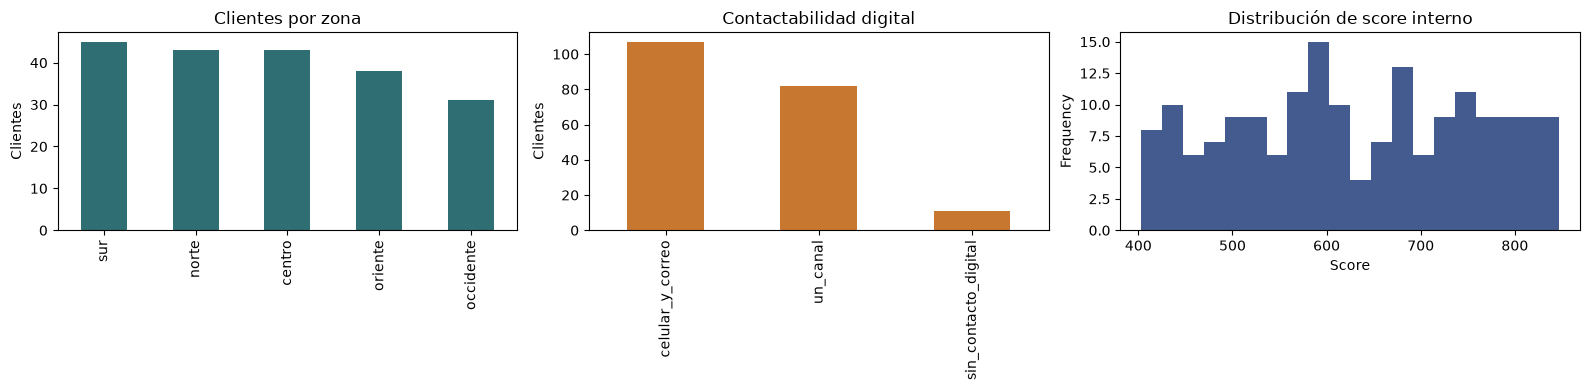

In [30]:
# Visualiza zona, contactabilidad y score interno.
figure, axes = plt.subplots(1, 3, figsize=(16, 4))

clients_by_zone['clientes'].plot(kind='bar', ax=axes[0], color='#2f6f73')
axes[0].set_title('Clientes por zona')
axes[0].set_xlabel('')
axes[0].set_ylabel('Clientes')

clients_by_contactability['clientes'].plot(kind='bar', ax=axes[1], color='#c7772f')
axes[1].set_title('Contactabilidad digital')
axes[1].set_xlabel('')
axes[1].set_ylabel('Clientes')

clients_eda['score_credito_interno'].plot(kind='hist', bins=20, ax=axes[2], color='#435b8f')
axes[2].set_title('Distribución de score interno')
axes[2].set_xlabel('Score')

plt.tight_layout()
plt.show()

## 7. Exploración de transacciones

In [31]:
# Resume fechas, cobertura y valor transaccional.
transaction_summary_data = {
    'fecha_min': [transactions['fecha_compra'].min()],
    'fecha_max': [transactions['fecha_compra'].max()],
    'clientes_unicos': [transactions['id_cliente'].nunique()],
    'tiendas_unicas': [transactions['id_tienda'].nunique()],
    'skus_unicos': [transactions['sku_producto'].nunique()],
    'categorias_unicas': [transactions['categoria_producto'].nunique()],
    'venta_total': [transactions['monto_pago'].sum()],
    'ticket_promedio': [transactions['monto_pago'].mean()],
    'ticket_mediano': [transactions['monto_pago'].median()],
}
transaction_summary = pd.DataFrame(transaction_summary_data)
transaction_summary

,fecha_min,fecha_max,clientes_unicos,tiendas_unicas,skus_unicos,categorias_unicas,venta_total,ticket_promedio,ticket_mediano
0,2023-01-02,2026-01-03,177,4,51,4,"1,069,803,374.5900","2,377,340.8324","2,430,371.7600"


In [32]:
# Estadísticos del monto pagado.
transaction_amount_summary = transactions['monto_pago'].describe()
transaction_amount_summary = transaction_amount_summary.to_frame('monto_pago')
transaction_amount_summary

,monto_pago
count,450.0000
mean,"2,377,340.8324"
std,"1,210,882.9269"
min,"155,220.9000"
25%,"1,293,657.5225"
50%,"2,430,371.7600"
75%,"3,420,796.6500"
max,"4,464,324.2300"


In [33]:
# Venta y ticket por categoría.
category_sales = transactions.groupby('categoria_producto')
category_sales = category_sales.agg(
    transacciones=('id_transaccion', 'count'),
    venta_total=('monto_pago', 'sum'),
    ticket_promedio=('monto_pago', 'mean'),
)
category_sales = category_sales.sort_values('venta_total', ascending=False)
category_sales

,transacciones,venta_total,ticket_promedio
categoria_producto,,,
refrigeracion,128,"300,572,327.0900","2,348,221.3054"
pequenos_electrodomesticos,115,"273,267,175.7500","2,376,236.3109"
lavado,104,"251,558,960.0600","2,418,836.1544"
coccion,103,"244,404,911.6900","2,372,863.2203"


In [34]:
# Venta y ticket por tienda.
store_sales = transactions.groupby('id_tienda')
store_sales = store_sales.agg(
    transacciones=('id_transaccion', 'count'),
    venta_total=('monto_pago', 'sum'),
    ticket_promedio=('monto_pago', 'mean'),
)
store_sales = store_sales.sort_values('venta_total', ascending=False)
store_sales

,transacciones,venta_total,ticket_promedio
id_tienda,,,
tienda_sur,117,"293,274,298.2200","2,506,617.9335"
tienda_occidente,113,"266,140,090.2500","2,355,222.0376"
tienda_norte,112,"264,180,157.1200","2,358,751.4029"
tienda_centro,108,"246,208,829.0000","2,279,711.3796"


In [35]:
# Venta y ticket por medio de pago.
payment_sales = transactions.groupby('medio_pago')
payment_sales = payment_sales.agg(
    transacciones=('id_transaccion', 'count'),
    venta_total=('monto_pago', 'sum'),
    ticket_promedio=('monto_pago', 'mean'),
)
payment_sales = payment_sales.sort_values('venta_total', ascending=False)
payment_sales

,transacciones,venta_total,ticket_promedio
medio_pago,,,
tarjeta_credito,118,"283,395,488.6200","2,401,656.6832"
tarjeta_debito,118,"270,650,483.8500","2,293,648.1682"
efectivo,111,"264,151,606.5000","2,379,744.2027"
credito_propio_retail,103,"251,605,795.6200","2,442,774.7148"


In [36]:
# Calcula venta mensual para observar estacionalidad y tendencia.
transactions_monthly = transactions.loc[:, :]
transactions_monthly['month'] = transactions_monthly['fecha_compra'].dt.to_period('M').dt.to_timestamp()
transactions_monthly = transactions_monthly.groupby('month')
transactions_monthly = transactions_monthly.agg(
    transacciones=('id_transaccion', 'count'),
    venta_total=('monto_pago', 'sum'),
)
transactions_monthly = transactions_monthly.reset_index()
transactions_monthly.head()

,month,transacciones,venta_total
0,2023-01-01,15,"35,486,375.9100"
1,2023-02-01,10,"20,546,657.9000"
2,2023-03-01,14,"40,566,571.3800"
3,2023-04-01,14,"30,653,963.6000"
4,2023-05-01,16,"39,872,802.0100"


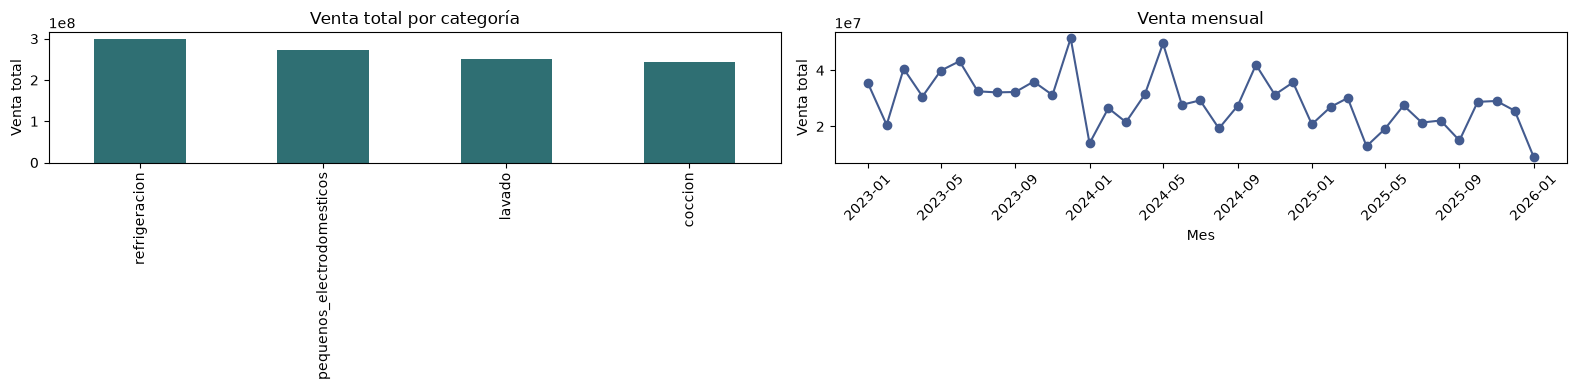

In [37]:
# Visualiza venta por categoría y evolución mensual.
figure, axes = plt.subplots(1, 2, figsize=(16, 4))

category_sales['venta_total'].plot(kind='bar', ax=axes[0], color='#2f6f73')
axes[0].set_title('Venta total por categoría')
axes[0].set_xlabel('')
axes[0].set_ylabel('Venta total')

axes[1].plot(transactions_monthly['month'], transactions_monthly['venta_total'], marker='o', color='#435b8f')
axes[1].set_title('Venta mensual')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Venta total')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Exploración de interacciones en tienda

In [38]:
# Resume fechas, cobertura y conversión en visitas físicas.
interaction_summary_data = {
    'fecha_min': [interactions['fecha_visita'].min()],
    'fecha_max': [interactions['fecha_visita'].max()],
    'clientes_unicos': [interactions['id_cliente'].nunique()],
    'tiendas_unicas': [interactions['id_tienda'].nunique()],
    'conversion_rate': [interactions['compro_en_visita'].mean()],
}
interaction_summary = pd.DataFrame(interaction_summary_data)
interaction_summary

,fecha_min,fecha_max,clientes_unicos,tiendas_unicas,conversion_rate
0,2023-01-03,2026-01-05,155,4,0.5567


In [39]:
# Distribución de motivos de visita.
visits_by_motive = interactions['motivo_visita'].value_counts(dropna=False)
visits_by_motive = visits_by_motive.to_frame('interacciones')
visits_by_motive

,interacciones
motivo_visita,
servicio_tecnico,81
pago_cuota_credito,74
reclamo,73
cotizacion,72


In [40]:
# Conversión por tienda.
conversion_by_store = interactions.groupby('id_tienda')
conversion_by_store = conversion_by_store.agg(
    interacciones=('id_interaccion', 'count'),
    conversion_rate=('compro_en_visita', 'mean'),
)
conversion_by_store = conversion_by_store.sort_values('conversion_rate', ascending=False)
conversion_by_store

,interacciones,conversion_rate
id_tienda,,
tienda_centro,89,0.6292
tienda_sur,67,0.5821
tienda_norte,68,0.5147
tienda_occidente,76,0.4868


In [41]:
# Conversión por motivo de visita.
conversion_by_motive = interactions.groupby('motivo_visita')
conversion_by_motive = conversion_by_motive.agg(
    interacciones=('id_interaccion', 'count'),
    conversion_rate=('compro_en_visita', 'mean'),
)
conversion_by_motive = conversion_by_motive.sort_values('conversion_rate', ascending=False)
conversion_by_motive

,interacciones,conversion_rate
motivo_visita,,
pago_cuota_credito,74,0.5811
cotizacion,72,0.5694
reclamo,73,0.5616
servicio_tecnico,81,0.5185


In [42]:
# Calcula conversión mensual.
interactions_monthly = interactions.loc[:, :]
interactions_monthly['month'] = interactions_monthly['fecha_visita'].dt.to_period('M').dt.to_timestamp()
interactions_monthly = interactions_monthly.groupby('month')
interactions_monthly = interactions_monthly.agg(
    interacciones=('id_interaccion', 'count'),
    conversion_rate=('compro_en_visita', 'mean'),
)
interactions_monthly = interactions_monthly.reset_index()
interactions_monthly.head()

,month,interacciones,conversion_rate
0,2023-01-01,6,0.3333
1,2023-02-01,6,0.6667
2,2023-03-01,10,0.3000
3,2023-04-01,9,0.3333
4,2023-05-01,8,0.7500


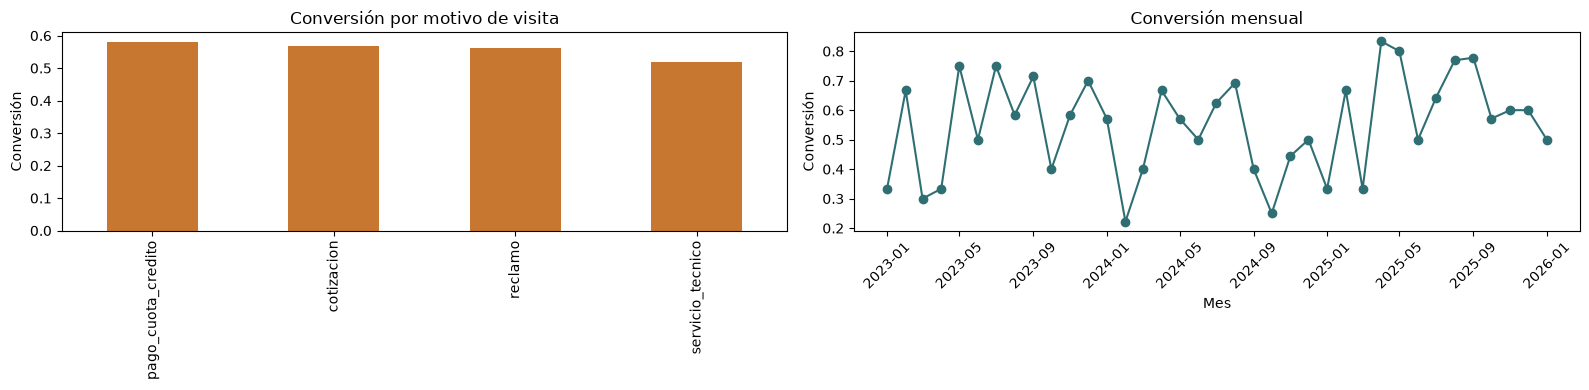

In [43]:
# Visualiza conversión por motivo y conversión mensual.
figure, axes = plt.subplots(1, 2, figsize=(16, 4))

conversion_by_motive['conversion_rate'].plot(kind='bar', ax=axes[0], color='#c7772f')
axes[0].set_title('Conversión por motivo de visita')
axes[0].set_xlabel('')
axes[0].set_ylabel('Conversión')

axes[1].plot(interactions_monthly['month'], interactions_monthly['conversion_rate'], marker='o', color='#2f6f73')
axes[1].set_title('Conversión mensual')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Conversión')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Cruces entre fuentes

In [44]:
# Agrega señales transaccionales por cliente.
client_transactions = transactions.groupby('id_cliente')
client_transactions = client_transactions.agg(
    total_transactions=('id_transaccion', 'count'),
    total_spend=('monto_pago', 'sum'),
    avg_ticket=('monto_pago', 'mean'),
    last_purchase_date=('fecha_compra', 'max'),
    distinct_categories=('categoria_producto', 'nunique'),
)
client_transactions = client_transactions.reset_index()
client_transactions.head()

,id_cliente,total_transactions,total_spend,avg_ticket,last_purchase_date,distinct_categories
0,cli_001,3,"9,590,991.0600","3,196,997.0200",2024-07-29,3
1,cli_002,1,"2,329,885.8000","2,329,885.8000",2025-10-13,1
2,cli_003,5,"14,846,198.8900","2,969,239.7780",2025-09-08,3
3,cli_005,1,"2,253,790.0500","2,253,790.0500",2023-02-10,1
4,cli_006,1,"1,592,298.8300","1,592,298.8300",2024-05-03,1


In [45]:
# Agrega señales de interacción por cliente.
client_interactions = interactions.groupby('id_cliente')
client_interactions = client_interactions.agg(
    total_interactions=('id_interaccion', 'count'),
    converted_interactions=('compro_en_visita', 'sum'),
    conversion_rate_history=('compro_en_visita', 'mean'),
    last_visit_date=('fecha_visita', 'max'),
)
client_interactions = client_interactions.reset_index()
client_interactions.head()

,id_cliente,total_interactions,converted_interactions,conversion_rate_history,last_visit_date
0,cli_001,2,1,0.5000,2025-12-23
1,cli_002,1,1,1.0000,2023-10-31
2,cli_003,2,1,0.5000,2025-05-03
3,cli_005,1,1,1.0000,2024-12-11
4,cli_008,3,2,0.6667,2025-10-23


In [46]:
# Construye una vista cliente 360 para exploración.
customer_360 = clients_eda.merge(client_transactions, on='id_cliente', how='left')
customer_360 = customer_360.merge(client_interactions, on='id_cliente', how='left')
customer_360['has_transactions'] = customer_360['total_transactions'].notna()
customer_360['has_interactions'] = customer_360['total_interactions'].notna()

customer_360_head = customer_360.head()
customer_360_head

,id_cliente,zona_geografica,antiguedad_meses,celular_contacto,email_contacto,score_credito_interno,has_cellphone,has_email,contactability,total_transactions,total_spend,avg_ticket,last_purchase_date,distinct_categories,total_interactions,converted_interactions,conversion_rate_history,last_visit_date,has_transactions,has_interactions
0,cli_001,norte,10,<NA>,usuario_1@correo.com,786.0000,False,True,un_canal,3.0000,"9,590,991.0600","3,196,997.0200",2024-07-29,3.0000,2.0000,1,0.5000,2025-12-23,True,True
1,cli_002,norte,51,<NA>,usuario_2@correo.com,523.0000,False,True,un_canal,1.0000,"2,329,885.8000","2,329,885.8000",2025-10-13,1.0000,1.0000,1,1.0000,2023-10-31,True,True
2,cli_003,oriente,46,2906803191,usuario_3@correo.com,553.0000,True,True,celular_y_correo,5.0000,"14,846,198.8900","2,969,239.7780",2025-09-08,3.0000,2.0000,1,0.5000,2025-05-03,True,True
3,cli_004,sur,9,7519610354,usuario_4@correo.com,473.0000,True,True,celular_y_correo,NaN,<NA>,<NA>,NaT,NaN,NaN,<NA>,<NA>,NaT,False,False
4,cli_005,sur,20,<NA>,usuario_5@correo.com,429.0000,False,True,un_canal,1.0000,"2,253,790.0500","2,253,790.0500",2023-02-10,1.0000,1.0000,1,1.0000,2024-12-11,True,True


In [47]:
# Resume cobertura y señales por zona geográfica.
coverage_by_zone = customer_360.groupby('zona_geografica')
coverage_by_zone = coverage_by_zone.agg(
    clientes=('id_cliente', 'count'),
    clientes_con_transacciones=('has_transactions', 'sum'),
    clientes_con_interacciones=('has_interactions', 'sum'),
    gasto_promedio=('total_spend', 'mean'),
    conversion_promedio=('conversion_rate_history', 'mean'),
)
coverage_by_zone['pct_con_transacciones'] = coverage_by_zone['clientes_con_transacciones'] / coverage_by_zone['clientes']
coverage_by_zone['pct_con_interacciones'] = coverage_by_zone['clientes_con_interacciones'] / coverage_by_zone['clientes']
coverage_by_zone = coverage_by_zone.sort_values('clientes', ascending=False)
coverage_by_zone

,clientes,clientes_con_transacciones,clientes_con_interacciones,gasto_promedio,conversion_promedio,pct_con_transacciones,pct_con_interacciones
zona_geografica,,,,,,,
sur,45,41,36,"5,664,525.4261",0.5833,0.9111,0.8000
centro,43,35,35,"5,297,654.6397",0.5710,0.8140,0.8140
norte,43,39,37,"5,884,757.3341",0.5360,0.9070,0.8605
oriente,38,32,26,"7,259,813.2725",0.5154,0.8421,0.6842
occidente,31,30,21,"6,344,011.9660",0.6032,0.9677,0.6774


In [48]:
# Cruza ventas por categoría y zona geográfica.
transactions_with_zone = transactions.merge(clients[['id_cliente', 'zona_geografica']], on='id_cliente', how='left')
category_by_zone = transactions_with_zone.pivot_table(
    index='zona_geografica',
    columns='categoria_producto',
    values='monto_pago',
    aggfunc='sum',
    fill_value=0,
)
category_by_zone

categoria_producto,coccion,lavado,pequenos_electrodomesticos,refrigeracion
zona_geografica,,,,
centro,"41,359,808.8400","31,346,408.6300","54,378,981.8500","58,332,713.0700"
norte,"45,078,454.8400","60,588,869.3200","56,876,607.0300","66,961,604.8400"
occidente,"58,182,247.8100","50,731,518.5000","43,290,674.8700","38,115,917.8000"
oriente,"60,827,120.3900","62,908,098.1500","59,849,054.1500","48,729,752.0300"
sur,"38,957,279.8100","45,984,065.4600","58,871,857.8500","88,432,339.3500"


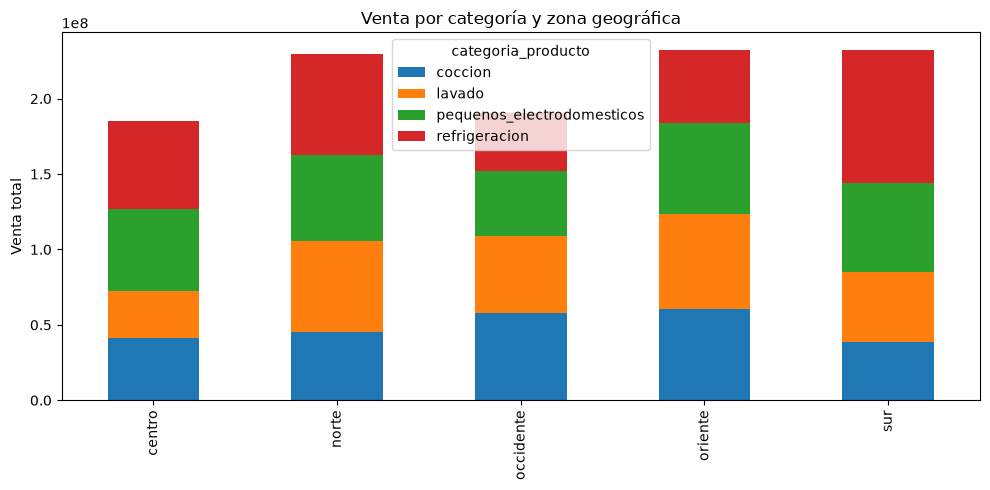

In [49]:
# Visualiza composición de ventas por categoría y zona.
figure, axis = plt.subplots(figsize=(10, 5))
category_by_zone.plot(kind='bar', stacked=True, ax=axis)
axis.set_title('Venta por categoría y zona geográfica')
axis.set_xlabel('')
axis.set_ylabel('Venta total')
plt.tight_layout()
plt.show()

## 10. Señales iniciales para modelado

Para un modelo de Next Best Action, las variables deben construirse evitando fuga de información. En entrenamiento, cada variable histórica debe calcularse solo con eventos anteriores a la visita evaluada.

In [50]:
# Construye señales exploratorias candidatas a modelado.
latest_event_date = max(transactions['fecha_compra'].max(), interactions['fecha_visita'].max())
modeling_signals = customer_360.loc[:, :]
modeling_signals['days_since_last_purchase'] = (latest_event_date - modeling_signals['last_purchase_date']).dt.days
modeling_signals['days_since_last_visit'] = (latest_event_date - modeling_signals['last_visit_date']).dt.days
modeling_signals['spend_per_interaction'] = modeling_signals['total_spend'] / modeling_signals['total_interactions']

candidate_features = [
    'zona_geografica',
    'antiguedad_meses',
    'score_credito_interno',
    'contactability',
    'total_transactions',
    'total_spend',
    'avg_ticket',
    'distinct_categories',
    'days_since_last_purchase',
    'total_interactions',
    'conversion_rate_history',
    'days_since_last_visit',
]
modeling_signals_preview = modeling_signals.loc[:, candidate_features].head(10)
modeling_signals_preview

,zona_geografica,antiguedad_meses,score_credito_interno,contactability,total_transactions,total_spend,avg_ticket,distinct_categories,days_since_last_purchase,total_interactions,conversion_rate_history,days_since_last_visit
0,norte,10,786.0000,un_canal,3.0000,"9,590,991.0600","3,196,997.0200",3.0000,525.0000,2.0000,0.5000,13.0000
1,norte,51,523.0000,un_canal,1.0000,"2,329,885.8000","2,329,885.8000",1.0000,84.0000,1.0000,1.0000,797.0000
2,oriente,46,553.0000,celular_y_correo,5.0000,"14,846,198.8900","2,969,239.7780",3.0000,119.0000,2.0000,0.5000,247.0000
3,sur,9,473.0000,celular_y_correo,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN
4,sur,20,429.0000,un_canal,1.0000,"2,253,790.0500","2,253,790.0500",1.0000,"1,060.0000",1.0000,1.0000,390.0000
5,sur,10,613.0000,celular_y_correo,1.0000,"1,592,298.8300","1,592,298.8300",1.0000,612.0000,NaN,<NA>,NaN
6,norte,8,468.0000,un_canal,1.0000,"2,954,334.1400","2,954,334.1400",1.0000,962.0000,NaN,<NA>,NaN
7,centro,27,530.0000,celular_y_correo,2.0000,"4,869,596.8100","2,434,798.4050",2.0000,616.0000,3.0000,0.6667,74.0000
8,norte,10,731.0000,celular_y_correo,2.0000,"4,002,073.5500","2,001,036.7750",2.0000,49.0000,1.0000,1.0000,613.0000
9,centro,38,<NA>,celular_y_correo,NaN,<NA>,<NA>,NaN,NaN,1.0000,0.0000,861.0000


## 11. Hallazgos iniciales

- La base contiene tres fuentes conectadas por `id_cliente` y dos tablas operativas conectadas también por `id_tienda`.
- La calidad de contacto digital es una restricción real del caso: hay clientes sin celular, sin correo o sin ambos canales.
- La tabla de interacciones contiene la variable objetivo natural para una primera aproximación: `compro_en_visita`.
- El dominio sugiere que no basta con predecir conversión; se necesita recomendar la siguiente mejor acción por cliente, tienda y categoría.
- Las variables históricas deben construirse con ventanas temporales para evitar fuga de información.
- Para monetización, las métricas relevantes deben incluir `precision@k`, `lift@k`, calibración y valor esperado, no solo accuracy.

Limitaciones de los datos actuales:

- No hay margen por categoría o SKU.
- No hay inventario por tienda.
- No hay identificación del asesor.
- No hay acción comercial ejecutada ni grupo control.
- No hay datos de garantía, mantenimiento o postventa más allá del motivo de visita.

Estas brechas no bloquean un MVP, pero sí delimitan hasta dónde se puede afirmar causalidad o impacto incremental.